# Final Project: Text Generation Using RNNs  
**Word-level and Character-level Generative Models on Two Contrasting Corpora**

This notebook is the technical deliverable for the Agile AI final project. It loads the four trained recurrent models, summarizes the datasets and training results, and demonstrates reusable text generation.

**Models included**
1. Shakespeare corpus – word-level
2. Shakespeare corpus – character-level
3. Social media corpus – word-level
4. Social media corpus – character-level

## Instructor quick start

Use the function `quick_generate(model_name, prompt, length, temperature)` in the notebook.

Valid `model_name` values:
- `shakespeare_word`
- `shakespeare_char`
- `social_word`
- `social_char`

Example:
```python
quick_generate("social_word", prompt="love", length=40, temperature=0.9)
```

In [ ]:
from pathlib import Path
import sys, json, inspect
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path("/Users/nicolasmaitland/Library/CloudStorage/OneDrive-DurhamCollege/Agile/Final Project/final_project_submission/technical")
ARTIFACTS_DIR = BASE_DIR / "artifacts"
MODELS_DIR = BASE_DIR / "models"

sys.path.append(str(BASE_DIR))
import project_helpers as ph

corpus_stats = json.loads((ARTIFACTS_DIR / "corpus_stats.json").read_text(encoding="utf-8"))
histories = json.loads((ARTIFACTS_DIR / "histories.json").read_text(encoding="utf-8"))
sample_outputs = json.loads((ARTIFACTS_DIR / "sample_outputs.json").read_text(encoding="utf-8"))
metrics_df = pd.read_csv(ARTIFACTS_DIR / "metrics_summary.csv")
metrics_df

,model_name,corpus_label,granularity,epochs_ran,train_loss,val_loss,train_accuracy,val_accuracy,train_perplexity,val_perplexity,num_sequences,vocab_size,model_file
0,shakespeare_char,Shakespeare (Hamlet),char,2,2.466859,2.379995,0.301387,0.313860,11.785373,10.804849,8730,38,/mnt/data/final_project_submission/technical/m...
1,shakespeare_word,Shakespeare (Hamlet),word,3,5.104443,5.751931,0.151350,0.139558,164.752341,314.798058,9962,4798,/mnt/data/final_project_submission/technical/m...
2,social_char,Social media tweets,char,3,2.526107,2.491551,0.279893,0.277264,12.504728,12.079997,10825,66,/mnt/data/final_project_submission/technical/m...
3,social_word,Social media tweets,word,3,5.636475,6.444998,0.130650,0.125527,280.472395,629.545425,11872,7469,/mnt/data/final_project_submission/technical/m...


## Dataset summary

The Shakespeare corpus uses a cleaned plain-text version of *Hamlet*.  
The social-media corpus uses the first 3,000 rows from a public tweet subset CSV.  
Both corpora were normalized to lowercase and saved inside the project folder for reproducibility.

In [2]:
pd.DataFrame([
    {"corpus": "Shakespeare", **corpus_stats["shakespeare"]},
    {"corpus": "Social media", **corpus_stats["social_media"]},
])

,corpus,source_file,word_count,char_count
0,Shakespeare,/mnt/data/final_project_submission/technical/d...,39863,174660
1,Social media,/mnt/data/final_project_submission/technical/d...,47502,216559


## Key preprocessing and model definitions

The helper module is included with the submission so the instructor can inspect the exact preprocessing logic, architecture classes, and loading functions used by the notebook.

In [3]:
print(inspect.getsource(ph.clean_shakespeare_text))
print(inspect.getsource(ph.clean_social_media_text))
print(inspect.getsource(ph.WordLSTMModel))
print(inspect.getsource(ph.CharGRUModel))

def clean_shakespeare_text(raw_path: str | Path) -> str:
    text = Path(raw_path).read_text(encoding="utf-8")
    start_marker = "ACT I"
    end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK HAMLET ***"
    start = text.find(start_marker)
    end = text.find(end_marker)
    if start == -1:
        start = 0
    if end == -1:
        end = len(text)
    text = text[start:end]
    text = normalize_basic_text(text)
    return text

def clean_social_media_text(csv_path: str | Path, num_rows: int = 3000) -> str:
    df = pd.read_csv(csv_path, encoding="latin1")
    texts = df["Text"].astype(str).tolist()[:num_rows]
    text = " ".join(texts)
    text = normalize_basic_text(text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

class WordLSTMModel(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int = 64, hidden_dim: int = 128, dropout: float = 0.2):
        super().__init__()
        self.embedding = nn.Embe

## Training summary

Below are the saved metrics from the training runs used for the final deliverables.

In [4]:
metrics_df[["model_name", "epochs_ran", "train_loss", "val_loss", "train_accuracy", "val_accuracy", "train_perplexity", "val_perplexity"]]

,model_name,epochs_ran,train_loss,val_loss,train_accuracy,val_accuracy,train_perplexity,val_perplexity
0,shakespeare_char,2,2.466859,2.379995,0.301387,0.313860,11.785373,10.804849
1,shakespeare_word,3,5.104443,5.751931,0.151350,0.139558,164.752341,314.798058
2,social_char,3,2.526107,2.491551,0.279893,0.277264,12.504728,12.079997
3,social_word,3,5.636475,6.444998,0.130650,0.125527,280.472395,629.545425


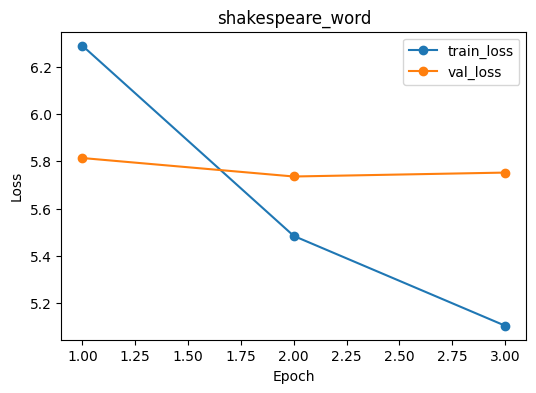

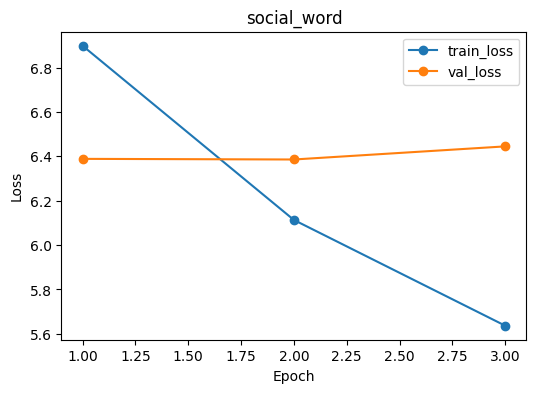

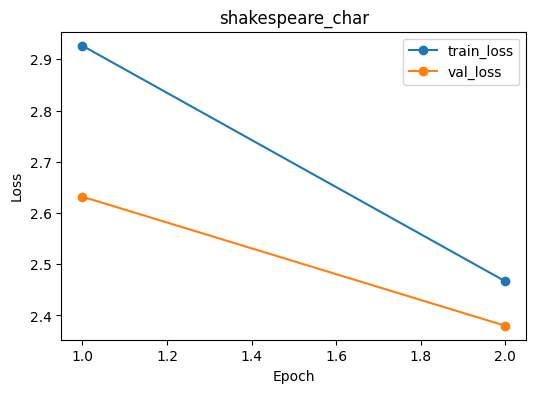

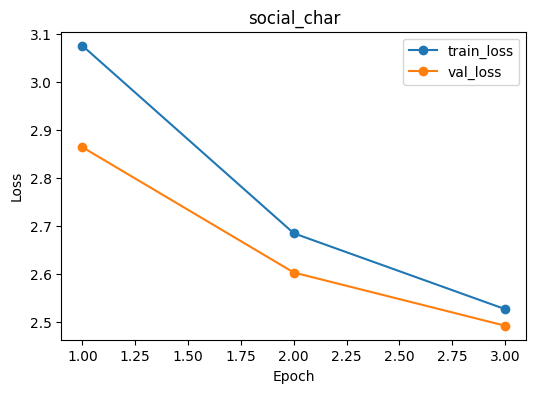

In [5]:
# Plot validation loss across epochs for each model
for model_name, rows in histories.items():
    df = pd.DataFrame(rows)
    plt.figure(figsize=(6, 4))
    plt.plot(df["epoch"], df["train_loss"], marker="o", label="train_loss")
    plt.plot(df["epoch"], df["val_loss"], marker="o", label="val_loss")
    plt.title(model_name)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

## Reusable loading and generation functions

In [6]:
MODEL_PATHS = {
    "shakespeare_word": MODELS_DIR / "shakespeare_word.h5",
    "shakespeare_char": MODELS_DIR / "shakespeare_char.h5",
    "social_word": MODELS_DIR / "social_word.h5",
    "social_char": MODELS_DIR / "social_char.h5",
}

def load_project_model(model_name: str):
    return ph.load_model_bundle(MODEL_PATHS[model_name])

def quick_generate(model_name: str, prompt: str, length: int | None = None, temperature: float | None = None):
    bundle = load_project_model(model_name)
    granularity = bundle["metadata"]["granularity"]
    if length is None:
        length = 40 if granularity == "word" else 160
    if temperature is None:
        temperature = 0.9 if granularity == "word" else 0.8
    return ph.generate_text(bundle, prompt=prompt, length=length, temperature=temperature)

demo = quick_generate("shakespeare_word", prompt="love", length=35, temperature=0.9)
print(demo)

love to, but, i will you, the castle. hamlet. i am, and the other of his, and for and, and, that i, as a thing,


## Sample outputs with the same prompt (`love`)

In [7]:
for model_name, rows in sample_outputs.items():
    print("=" * 100)
    print(model_name)
    for row in rows:
        print(f"temperature={row['temperature']}")
        print(row["text"])
        print()

shakespeare_word
temperature=0.8
love; and the body and, and in the, and to him, you it to the, of the, and you, and, and i, my lord. i have

temperature=1.0
love, and not to the the castle scene. and i am the the world, and not, i have to the polack of your!. i do, but and, and

temperature=1.2
love; for it. king. how not, that the thing of the body of his, or in the polack of his of, and that the man with you, and in

social_word
temperature=0.8
love, just just a day, i think it.. i need to get a the day! i dont be to get a movie,. is not. i want to do

temperature=1.0
love i just do........... so sad i just have to be the same for a week? just on the way.. i don't

temperature=1.2
love. but it and i just feel was i just want to go the rain i need to go my mom to get a movie and i feel want a few days for, so

shakespeare_char
temperature=0.7
love t in werandenghe sout aland in iat. het ar by hand hit il. tht hat it he heanst and ien thes. the torel thind ine thel thes at hen send th

## Qualitative observations

- **Corpus effect:** the Shakespeare models lean toward archaic wording, dramatic phrasing, names, and court-like sentence structure. The social-media models are shorter, more casual, and more fragmentary.
- **Word vs. character effect:** the word-level models produce more recognizable local semantics, while the character-level models capture spelling patterns, punctuation, and surface rhythm more strongly than full sentence coherence.
- **Common failure modes:** repetition, unfinished thoughts, and drifting syntax remain visible in all four models, especially for the smaller character-level runs.
- **Interpretation:** even with CPU-friendly training settings, the notebook still shows the assignment's central comparison: corpus choice changes *style*, while token granularity changes *coherence versus texture*.

## Dataset source links

See `dataset_sources.md` in the project folder for the original download links and prepared-file references.